#### Homework 2: California housing dataset - predict the price of a house

In [57]:
# Import Libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error,r2_score

import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# Load the California housing dataset
california_housing_data = datasets.fetch_california_housing(as_frame=True)

# Display the description of the dataset
print(california_housing_data.DESCR)

# Convert dataset object into a dataframe table
df = california_housing_data.frame

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [31]:
# Display the first few rows of the dataset
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [43]:
# Convert to lowercase
df.columns = df.columns.str.lower()

# Display the column names after convert
df.columns

Index(['medinc', 'houseage', 'averooms', 'avebedrms', 'population', 'aveoccup',
       'latitude', 'longitude', 'medhouseval'],
      dtype='object')

In [47]:
# Check for missing values in the dataset
df.isnull().sum()

medinc         0
houseage       0
averooms       0
avebedrms      0
population     0
aveoccup       0
latitude       0
longitude      0
medhouseval    0
dtype: int64

In [45]:
# Get the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   medinc       20640 non-null  float64
 1   houseage     20640 non-null  float64
 2   averooms     20640 non-null  float64
 3   avebedrms    20640 non-null  float64
 4   population   20640 non-null  float64
 5   aveoccup     20640 non-null  float64
 6   latitude     20640 non-null  float64
 7   longitude    20640 non-null  float64
 8   medhouseval  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [48]:
# Get the summary statistics of the dataset
df.describe()

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude,medhouseval
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [53]:
# Split the dataset into features (X)
X = df.drop(columns=["medhouseval"])

X

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [56]:
# Split the dataset Target variable (Y)
Y = df["medhouseval"]

Y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: medhouseval, Length: 20640, dtype: float64

In [58]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=42 )

In [64]:
# Reset the index of the training and testing sets

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)
Y_test  = Y_test.reset_index(drop=True)

# Display the shapes of the training and testing sets
X_train.shape,Y_train.shape
X_test.shape,Y_test.shape

print("X_train shape:", X_train.shape, "Y_train shape:", Y_train.shape, "X_test shape:", X_test.shape, "Y_test shape:", Y_test.shape)

X_train shape: (16512, 8) Y_train shape: (16512,) X_test shape: (4128, 8) Y_test shape: (4128,)


In [65]:
# Create a linear regression model
model = linear_model.LinearRegression()

In [66]:
# Train the model using the training data
model.fit(X_train, Y_train)

LinearRegression()

In [67]:
# Make predictions using the testing data
Y_pred = model.predict(X_test)

In [71]:
# Evaluate the model performance
coefficients = model.coef_
intercept = model.intercept_
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Coefficients:", coefficients)
print("Intercept:", intercept)
print("Mean Squared Error:", mse)
print("Determination (r2):", r2)


Coefficients: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept: -37.02327770606403
Mean Squared Error: 0.5558915986952444
Determination (r2): 0.5757877060324508


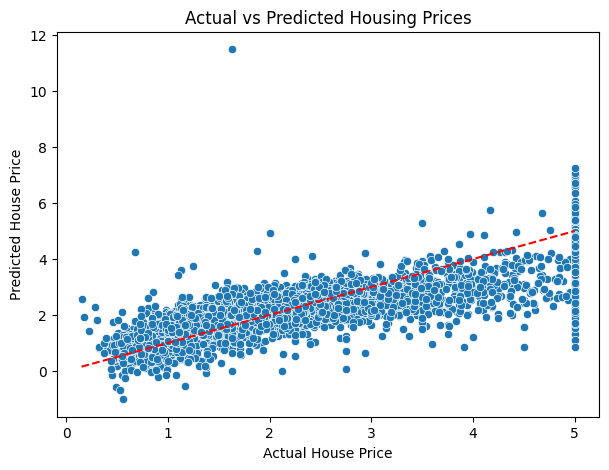

In [72]:
# Visualize the actual vs predicted values using a scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(x=Y_test, y=Y_pred)

plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color="red", linestyle="--")

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

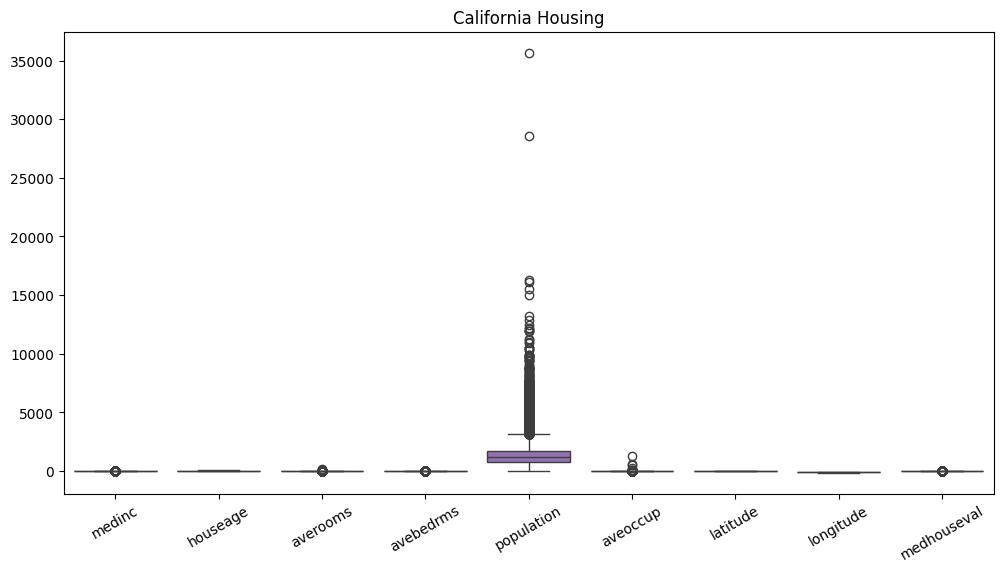

In [74]:
# Visualize the distribution of the features in the dataset using box plots

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=30)
plt.title("California Housing")
plt.show()